🚀 正在解析 RAGAS 评估数据并绘制柱状图...
📥 正在加载 Dense [Raw] 数据...
📥 正在加载 Dense [Rerank] 数据...
📥 正在加载 Bm25 [Raw] 数据...
📥 正在加载 Bm25 [Rerank] 数据...
📥 正在加载 Hybrid [Raw] 数据...
📥 正在加载 Hybrid [Rerank] 数据...
✅ Context 两指标图已保存至: ..\RAGAS_completed\chunk\RAG_AS\Final_RAGAS_ContextMetrics-chunk.png


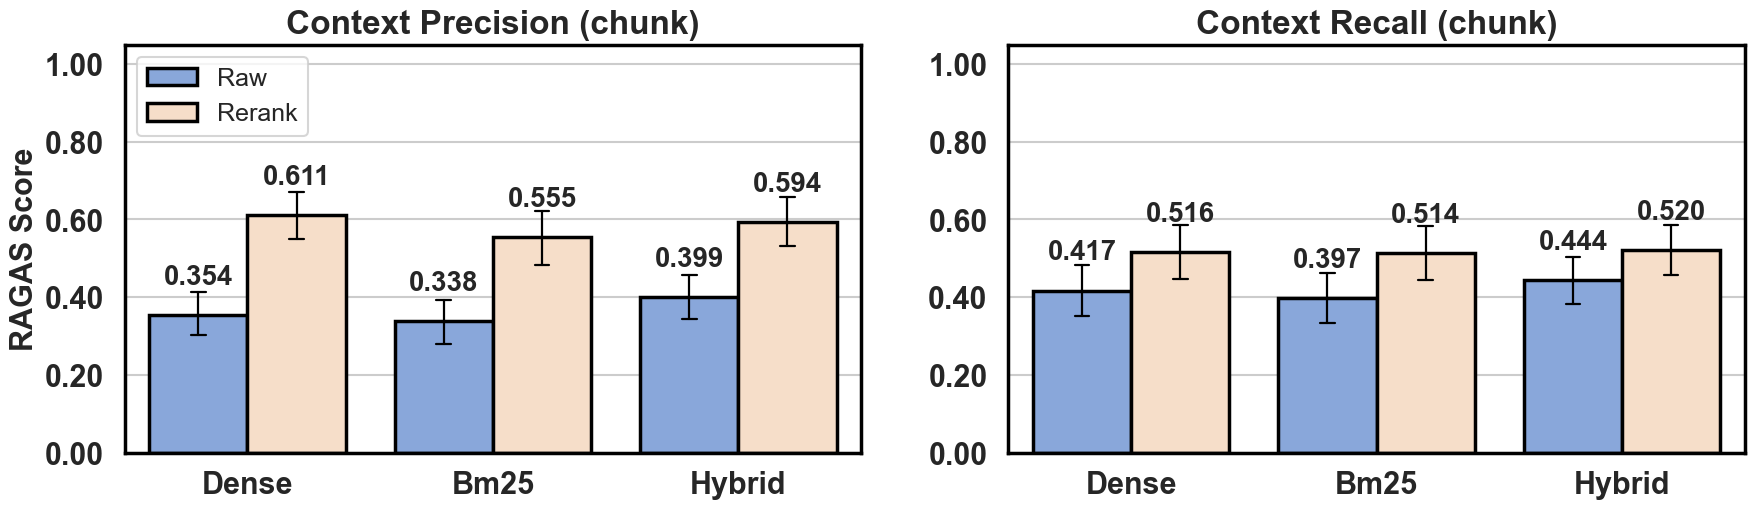

✅ Answer 三指标图已保存至: ..\RAGAS_completed\chunk\RAG_AS\Final_RAGAS_AnswerMetrics-chunk.png


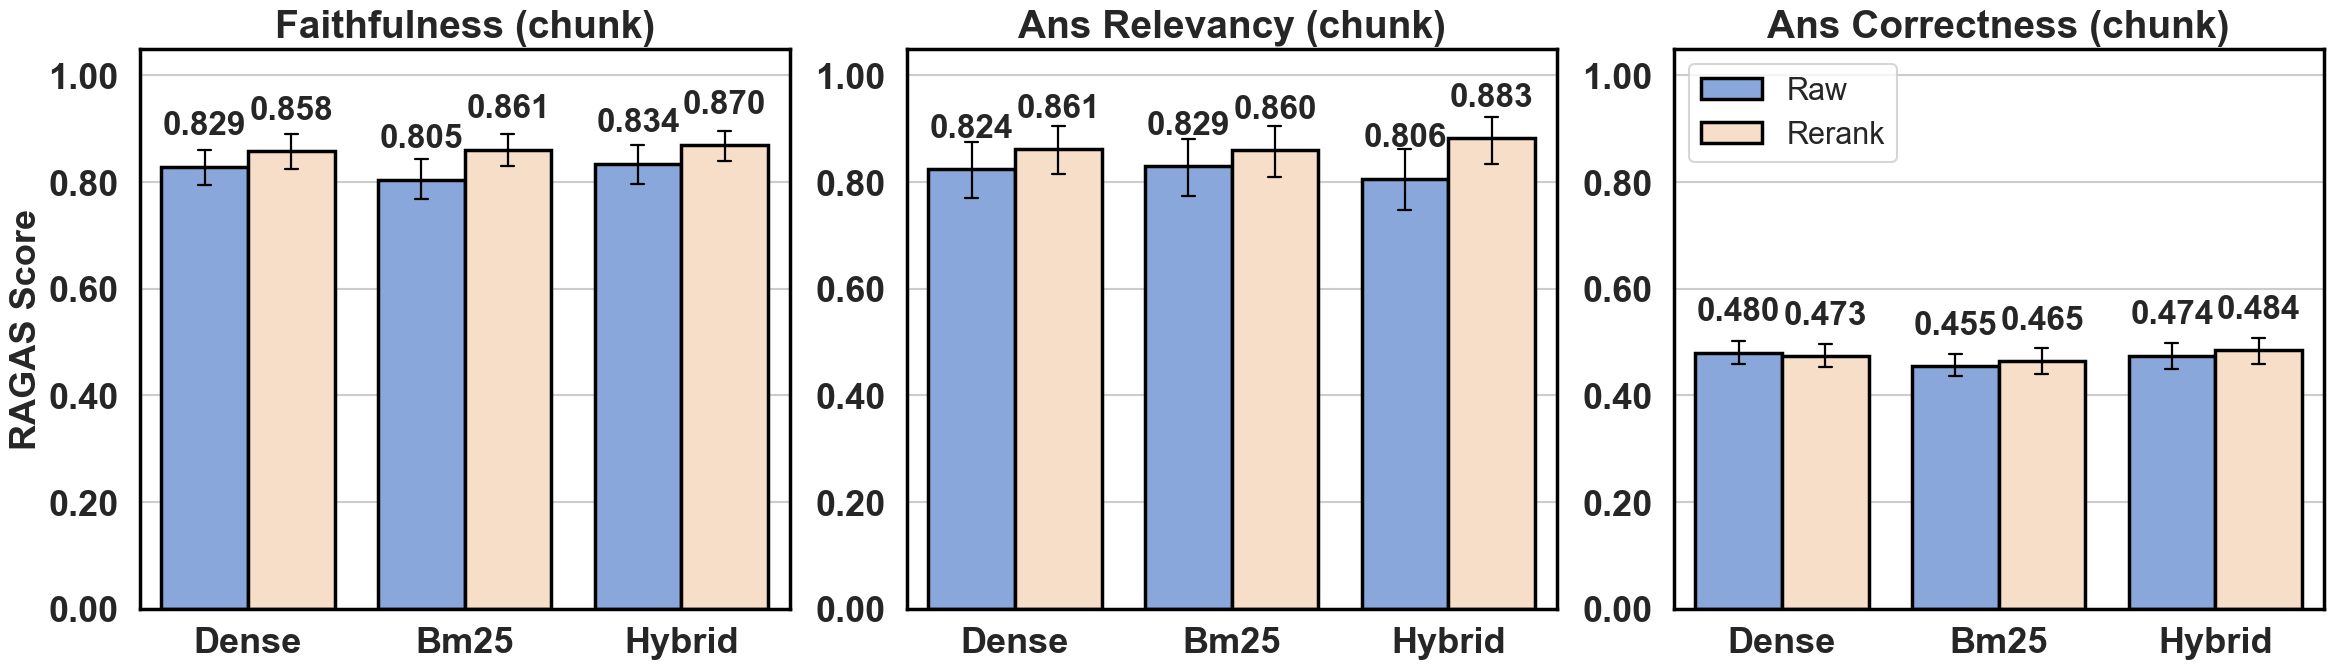

In [13]:
# -*- coding: utf-8 -*-
# RAGAS - split five metrics into separate panels
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from matplotlib.ticker import FormatStrFormatter

warnings.filterwarnings("ignore")

# ==========================================
# 1. 路径配置
# ==========================================
BASE_DIR = r"..\RAGAS_completed\chunk\RAG_AS"

OUTPUT_CONTEXT_PATH = os.path.join(BASE_DIR, "Final_RAGAS_ContextMetrics-chunk.png")
OUTPUT_ANSWER_PATH = os.path.join(BASE_DIR, "Final_RAGAS_AnswerMetrics-chunk.png")

MODES = ["Dense", "Bm25", "Hybrid"]

# ==========================================
# 2. 上下两部分分别设置字号
# ==========================================
# ===== Context 两图字号（上面两张）=====
FS_TITLE_CTX = 24
FS_LABEL_CTX = 22
FS_TICK_CTX = 22
FS_ANNOT_CTX = 20
FS_LEGEND_CTX = 18
FS_LEGEND_TITLE_CTX = 18

# ===== Answer 三图字号（下面三张）=====
FS_TITLE_ANS = 28
FS_LABEL_ANS = 26
FS_TICK_ANS = 26
FS_ANNOT_ANS = 24
FS_LEGEND_ANS = 22
FS_LEGEND_TITLE_ANS = 22

# RAGAS 原始列名到图表展示名的映射
METRIC_MAPPING = [
    ('context_precision', 'Ctx Precision', 'Context'),
    ('context_recall', 'Ctx Recall', 'Context'),
    ('faithfulness', 'Faithfulness', 'Answer'),
    ('answer_relevancy', 'Ans Relevancy', 'Answer'),
    ('answer_correctness', 'Ans Correctness', 'Answer')
]

# ==========================================
# 3. 数据加载与重构
# ==========================================
def load_and_melt_ragas_data():
    all_data = []

    for mode in MODES:
        folder_name = mode if mode != "Bm25" else "Bm25"
        raw_path = os.path.join(BASE_DIR, folder_name, "ragas_raw_detail.csv")
        rerank_path = os.path.join(BASE_DIR, folder_name, "ragas_rerank_detail.csv")

        # 加载 Raw 数据
        if os.path.exists(raw_path):
            print(f"📥 正在加载 {mode} [Raw] 数据...")
            df_raw = pd.read_csv(raw_path)
            for raw_col, nice_name, group in METRIC_MAPPING:
                if raw_col in df_raw.columns:
                    for val in df_raw[raw_col].dropna():
                        all_data.append({
                            'Mode': mode,
                            'Group': group,
                            'Metric': nice_name,
                            'Condition': 'Raw',
                            'Score': float(val)
                        })
        else:
            print(f"⚠️ 找不到文件: {raw_path}")

        # 加载 Rerank 数据
        if os.path.exists(rerank_path):
            print(f"📥 正在加载 {mode} [Rerank] 数据...")
            df_rerank = pd.read_csv(rerank_path)
            for raw_col, nice_name, group in METRIC_MAPPING:
                if raw_col in df_rerank.columns:
                    for val in df_rerank[raw_col].dropna():
                        all_data.append({
                            'Mode': mode,
                            'Group': group,
                            'Metric': nice_name,
                            'Condition': 'Rerank',
                            'Score': float(val)
                        })
        else:
            print(f"⚠️ 找不到文件: {rerank_path}")

    return pd.DataFrame(all_data)

# ==========================================
# 4. 通用绘图辅助函数
# ==========================================
def annotate_bars(ax, fs_annot, y_offset=18):
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(
                f"{height:.3f}",
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va='bottom',
                fontsize=fs_annot,
                fontweight='bold',
                xytext=(0, y_offset),
                textcoords='offset points'
            )

def style_spines(ax, lw=2.5):
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(lw)

def draw_metric_panel(ax, subset, title, palette, order,
                      ylim=(0.0, 1.05), yticks=None,
                      show_legend=False, show_ylabel=True,
                      fs_title=24, fs_label=22, fs_tick=22,
                      fs_annot=20, fs_legend=18, fs_legend_title=18,
                      annot_offset=18):
    sns.barplot(
        data=subset,
        x="Mode",
        y="Score",
        hue="Condition",
        order=order,
        palette=palette,
        ax=ax,
        capsize=0.12,
        errcolor='black',
        errwidth=1.6,
        edgecolor='black',
        linewidth=2.5
    )

    # 标题与坐标轴标题
    ax.set_title(title, fontsize=fs_title, fontweight='bold', pad=8)
    ax.set_xlabel("")

    if show_ylabel:
        ax.set_ylabel("RAGAS Score", fontsize=fs_label, fontweight='bold')
    else:
        ax.set_ylabel("")

    # x轴刻度
    ax.set_xticklabels(order, fontsize=fs_tick, fontweight='bold')

    # y轴范围与刻度
    ax.set_ylim(*ylim)
    if yticks is not None:
        ax.set_yticks(yticks)
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    ax.tick_params(axis='y', labelsize=fs_tick, pad=6)
    for label in ax.get_yticklabels():
        label.set_fontsize(fs_tick)
        label.set_fontweight('bold')

    # 数值标签与边框
    annotate_bars(ax, fs_annot=fs_annot, y_offset=annot_offset)
    style_spines(ax, lw=2.5)

    # 图例
    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles, labels,
            fontsize=fs_legend,
            title_fontsize=fs_legend_title,
            loc='upper left'
        )
    else:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

# ==========================================
# 5. 绘制 Context 两指标
# ==========================================
def plot_context_metrics(df):
    sns.set_theme(style="whitegrid", context="talk", font_scale=1.0)

    palette = {"Raw": (124/255, 164/255, 231/255), 
           "Rerank": (254/255, 222/255, 193/255)}
    
    order = ["Dense", "Bm25", "Hybrid"]
    ragas_ylim = (0.0, 1.05)
    ragas_yticks = np.arange(0.0, 1.01, 0.2)

    context_metrics = ["Ctx Precision", "Ctx Recall"]
    context_titles = ["Context Precision (chunk)", "Context Recall (chunk)"]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    plt.subplots_adjust(left=0.08, right=0.98, top=0.88, bottom=0.20, wspace=0.20)

    for i, metric in enumerate(context_metrics):
        subset = df[df["Metric"] == metric]
        draw_metric_panel(
            ax=axes[i],
            subset=subset,
            title=context_titles[i],
            palette=palette,
            order=order,
            ylim=ragas_ylim,
            yticks=ragas_yticks,
            show_legend=(i == 0),
            show_ylabel=(i == 0),
            fs_title=FS_TITLE_CTX,
            fs_label=FS_LABEL_CTX,
            fs_tick=FS_TICK_CTX,
            fs_annot=FS_ANNOT_CTX,
            fs_legend=FS_LEGEND_CTX,
            fs_legend_title=FS_LEGEND_TITLE_CTX,
            annot_offset=18
        )

    plt.savefig(OUTPUT_CONTEXT_PATH, dpi=300)
    print(f"✅ Context 两指标图已保存至: {OUTPUT_CONTEXT_PATH}")
    plt.show()

# ==========================================
# 6. 绘制 Answer 三指标
# ==========================================
def plot_answer_metrics(df):
    sns.set_theme(style="whitegrid", context="talk", font_scale=1.0)

    palette = {"Raw": (124/255, 164/255, 231/255), 
           "Rerank": (254/255, 222/255, 193/255)}
    
    order = ["Dense", "Bm25", "Hybrid"]
    ragas_ylim = (0.0, 1.05)
    ragas_yticks = np.arange(0.0, 1.01, 0.2)

    answer_metrics = ["Faithfulness", "Ans Relevancy", "Ans Correctness"]
    answer_titles  = ["Faithfulness (chunk)", "Ans Relevancy (chunk)", "Ans Correctness (chunk)"]
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    plt.subplots_adjust(left=0.07, right=0.98, top=0.88, bottom=0.18, wspace=0.18)

    for i, metric in enumerate(answer_metrics):
        subset = df[df["Metric"] == metric]
        draw_metric_panel(
            ax=axes[i],
            subset=subset,
            title=answer_titles[i],
            palette=palette,
            order=order,
            ylim=ragas_ylim,
            yticks=ragas_yticks,
            show_legend=(i == 2),   # 图例放在 Ans Correctness
            show_ylabel=(i == 0),
            fs_title=FS_TITLE_ANS,
            fs_label=FS_LABEL_ANS,
            fs_tick=FS_TICK_ANS,
            fs_annot=FS_ANNOT_ANS,
            fs_legend=FS_LEGEND_ANS,
            fs_legend_title=FS_LEGEND_TITLE_ANS,
            annot_offset=18
        )

    plt.savefig(OUTPUT_ANSWER_PATH, dpi=300)
    print(f"✅ Answer 三指标图已保存至: {OUTPUT_ANSWER_PATH}")
    plt.show()

# ==========================================
# 7. 主程序
# ==========================================
if __name__ == "__main__":
    print("🚀 正在解析 RAGAS 评估数据并绘制柱状图...")
    df_melted = load_and_melt_ragas_data()

    if not df_melted.empty:
        plot_context_metrics(df_melted)
        plot_answer_metrics(df_melted)
    else:
        print("❌ 未加载到有效数据，请检查基础路径 BASE_DIR。")

🚀 正在解析 RAGAS 数据并生成单张风格统一图表...
📥 正在加载 Dense [Raw] 数据...
📥 正在加载 Dense [Rerank] 数据...
📥 正在加载 Bm25 [Raw] 数据...
📥 正在加载 Bm25 [Rerank] 数据...
📥 正在加载 Hybrid [Raw] 数据...
📥 正在加载 Hybrid [Rerank] 数据...
✅ 风格统一后的单图已保存至: ..\RAGAS_completed\chunk\RAG_AS\Paper_Style_Ablation_BarChart-chunk.png


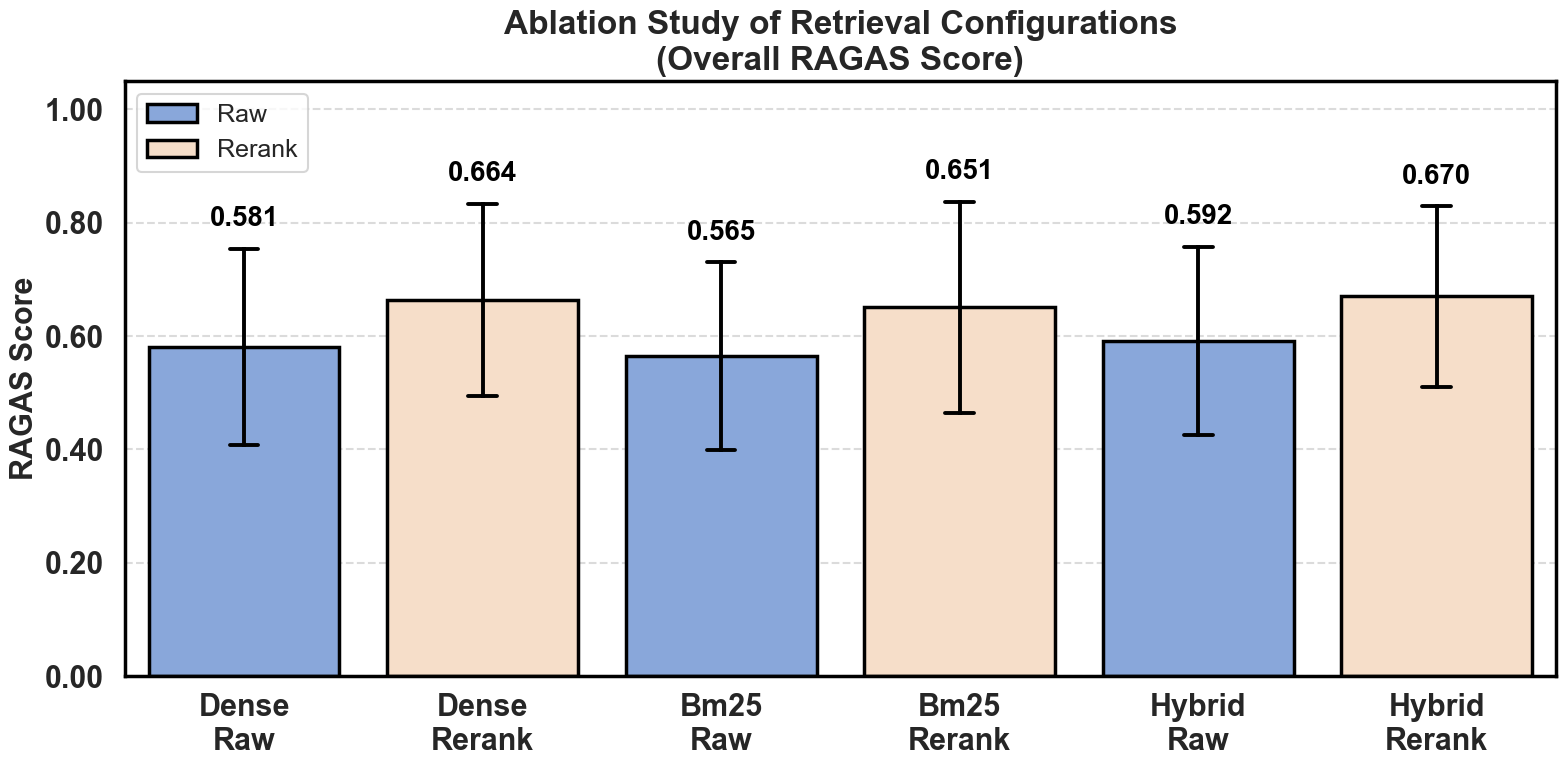

In [9]:
# -*- coding: utf-8 -*-
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from matplotlib.ticker import FormatStrFormatter

warnings.filterwarnings("ignore")

# ==========================================
# 1. 路径配置
# ==========================================
BASE_DIR = r"..\RAGAS_completed\chunk\RAG_AS"
OUTPUT_PLOT_PATH = os.path.join(BASE_DIR, "Paper_Style_Ablation_BarChart-chunk.png")

# 按模型演进逻辑排序：Bm25是最基础的，Hybrid是最复杂的
MODES = ["Dense", "Bm25", "Hybrid"]

METRIC_COLS = [
    'context_precision',
    'context_recall',
    'faithfulness',
    'answer_relevancy',
    'answer_correctness'
]

# ==========================================
# 2. 全局字号（统一到第一个脚本风格）
# ==========================================
FS_TITLE = 24
FS_LABEL = 22
FS_TICK = 22
FS_ANNOT = 20
FS_LEGEND = 18
FS_LEGEND_TITLE = 18

# 统一配色（和第一个脚本一致）
PALETTE = {"Raw": (124/255, 164/255, 231/255), 
           "Rerank": (254/255, 222/255, 193/255)}

# ==========================================
# 3. 数据加载与重构
# ==========================================
def load_paper_style_data():
    all_scores = []

    for mode in MODES:
        folder_name = mode
        raw_path = os.path.join(BASE_DIR, folder_name, "ragas_raw_detail.csv")
        rerank_path = os.path.join(BASE_DIR, folder_name, "ragas_rerank_detail.csv")

        configs = [
            (raw_path, 'Raw'),
            (rerank_path, 'Rerank')
        ]

        for path, condition in configs:
            if os.path.exists(path):
                print(f"📥 正在加载 {mode} [{condition}] 数据...")
                df = pd.read_csv(path)

                valid_cols = [col for col in METRIC_COLS if col in df.columns]

                if valid_cols:
                    # 每个问题的综合平均分
                    df['question_overall_score'] = df[valid_cols].mean(axis=1)

                    for val in df['question_overall_score'].dropna():
                        all_scores.append({
                            'Setting': f"{mode}\n{condition}",
                            'Score': float(val),
                            'Mode': mode,
                            'Condition': condition
                        })
            else:
                print(f"⚠️ 找不到文件: {path}")

    return pd.DataFrame(all_scores)

# ==========================================
# 4. 绘图辅助函数
# ==========================================
def style_spines(ax, lw=2.5):
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(lw)


def annotate_group_means(ax, df):
    grouped = df.groupby('Setting', sort=False)['Score'].mean()
    for i, (setting, mean_score) in enumerate(grouped.items()):
        std_val = df[df['Setting'] == setting]['Score'].std()
        std_val = 0.0 if np.isnan(std_val) else float(std_val)

        ax.annotate(
            f'{mean_score:.3f}',
            xy=(i, mean_score + std_val),
            xytext=(0, 12),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=FS_ANNOT,
            fontweight='bold',
            color='black'
        )

# ==========================================
# 5. 绘图逻辑
# ==========================================
def plot_paper_style_chart(df):
    # 统一成第一个脚本的整体风格
    sns.set_theme(style="whitegrid", context="talk", font_scale=1.0)

    fig, ax = plt.subplots(figsize=(16, 8))

    sns.barplot(
        data=df,
        x='Setting',
        y='Score',
        hue='Condition',
        palette=PALETTE,
        errorbar='sd',
        capsize=0.12,
        errcolor='black',
        errwidth=2.8,
        edgecolor='black',
        linewidth=2.5,
        dodge=False,
        ax=ax
    )

    # 标题与坐标轴
    ax.set_title(
        "Ablation Study of Retrieval Configurations\n(Overall RAGAS Score)",
        fontsize=FS_TITLE,
        fontweight='bold',
        pad=8
    )
    ax.set_xlabel("")
    ax.set_ylabel("RAGAS Score", fontsize=FS_LABEL, fontweight='bold')

    # y轴范围和格式
    ax.set_ylim(0.0, 1.05)
    ax.set_yticks(np.arange(0.0, 1.01, 0.2))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    # 刻度字体统一
    ax.tick_params(axis='x', labelsize=FS_TICK)
    ax.tick_params(axis='y', labelsize=FS_TICK, pad=6)

    for label in ax.get_xticklabels():
        label.set_fontsize(FS_TICK)
        label.set_fontweight('bold')

    for label in ax.get_yticklabels():
        label.set_fontsize(FS_TICK)
        label.set_fontweight('bold')

    # 数值标注：保持单张图逻辑不变，只统一样式
    annotate_group_means(ax, df)

    # 图例：改成第一个脚本那种无边框、左上
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles, labels,
        fontsize=FS_LEGEND,
        title_fontsize=FS_LEGEND_TITLE,
        loc='upper left'
    )
    # 边框与网格
    style_spines(ax, lw=2.5)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.xaxis.grid(False)

    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT_PATH, dpi=300)
    print(f"✅ 风格统一后的单图已保存至: {OUTPUT_PLOT_PATH}")
    plt.show()


if __name__ == "__main__":
    print("🚀 正在解析 RAGAS 数据并生成单张风格统一图表...")
    df_scores = load_paper_style_data()
    if not df_scores.empty:
        plot_paper_style_chart(df_scores)
    else:
        print("❌ 未加载到有效数据，请检查基础路径 BASE_DIR。")


In [11]:
# -*- coding: utf-8 -*-
# 计算 RAGAS Paper-Style 柱状图误差棒数值（按 mean + 95% bootstrap CI 思路）
import os
import numpy as np
import pandas as pd

BASE_DIR = r"..\RAGAS_completed\chunk\RAG_AS"
OUTPUT_CSV = os.path.join(BASE_DIR, "paper_style_errorbar_summary.csv")

MODES = ["Bm25", "Dense", "Hybrid"]

METRIC_COLS = [
    "context_precision",
    "context_recall",
    "faithfulness",
    "answer_relevancy",
    "answer_correctness"
]

N_BOOT = 1000
CI = 95
RANDOM_SEED = 42


def load_paper_style_data():
    all_scores = []

    for mode in MODES:
        raw_path = os.path.join(BASE_DIR, mode, "ragas_raw_detail.csv")
        rerank_path = os.path.join(BASE_DIR, mode, "ragas_rerank_detail.csv")

        configs = [
            (raw_path, "Basic (No Rerank)"),
            (rerank_path, "+ Rerank")
        ]

        for path, condition in configs:
            if not os.path.exists(path):
                print(f"⚠️ 找不到文件: {path}")
                continue

            print(f"📥 正在加载 {mode} [{condition}] 数据...")
            df = pd.read_csv(path)

            valid_cols = [col for col in METRIC_COLS if col in df.columns]
            if not valid_cols:
                print(f"⚠️ 文件中没有有效的 RAGAS 指标列: {path}")
                continue

            # 对每个问题先求 overall score
            df["question_overall_score"] = df[valid_cols].mean(axis=1)

            for val in df["question_overall_score"].dropna():
                all_scores.append({
                    "Mode": mode,
                    "Condition": condition,
                    "Setting": f"{mode}\n{condition}",
                    "Score": float(val)
                })

    return pd.DataFrame(all_scores)


def bootstrap_ci_mean(values, n_boot=1000, ci=95, seed=42):
    """对均值做 bootstrap，返回 (mean, ci_low, ci_high)"""
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    n = len(values)
    if n == 0:
        return np.nan, np.nan, np.nan

    mean_val = np.mean(values)

    if n == 1:
        return mean_val, mean_val, mean_val

    rng = np.random.default_rng(seed)
    boot_means = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        boot_means[i] = np.mean(sample)

    alpha = (100 - ci) / 2
    ci_low = np.percentile(boot_means, alpha)
    ci_high = np.percentile(boot_means, 100 - alpha)

    return mean_val, ci_low, ci_high


def summarize_errorbars(df):
    rows = []

    grouped = df.groupby(["Mode", "Condition", "Setting"], sort=False)

    for (mode, condition, setting), g in grouped:
        vals = g["Score"].dropna().to_numpy(dtype=float)

        n = len(vals)
        mean_val = np.mean(vals) if n > 0 else np.nan
        std_val = np.std(vals, ddof=1) if n > 1 else 0.0
        se_val = std_val / np.sqrt(n) if n > 1 else 0.0

        mean_boot, ci_low, ci_high = bootstrap_ci_mean(
            vals,
            n_boot=N_BOOT,
            ci=CI,
            seed=RANDOM_SEED
        )

        rows.append({
            "Mode": mode,
            "Condition": condition,
            "Setting": setting,
            "n": n,
            "mean": round(mean_boot, 6),
            "std": round(std_val, 6),
            "se": round(se_val, 6),
            "ci_low": round(ci_low, 6),
            "ci_high": round(ci_high, 6),
            "err_low": round(mean_boot - ci_low, 6),
            "err_high": round(ci_high - mean_boot, 6),
        })

    out = pd.DataFrame(rows)

    # 按你设定的模型顺序排序
    mode_order = {m: i for i, m in enumerate(MODES)}
    cond_order = {"Basic (No Rerank)": 0, "+ Rerank": 1}

    out["mode_order"] = out["Mode"].map(mode_order)
    out["cond_order"] = out["Condition"].map(cond_order)

    out = (
        out.sort_values(["mode_order", "cond_order"])
           .drop(columns=["mode_order", "cond_order"])
           .reset_index(drop=True)
    )
    return out


if __name__ == "__main__":
    df = load_paper_style_data()

    if df.empty:
        print("❌ 没有加载到数据")
    else:
        summary = summarize_errorbars(df)

        print("\n================ RAGAS 误差棒统计结果 ================\n")
        print(summary.to_string(index=False))

        summary.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
        print(f"\n✅ 已保存到: {OUTPUT_CSV}")

📥 正在加载 Bm25 [Basic (No Rerank)] 数据...
📥 正在加载 Bm25 [+ Rerank] 数据...
📥 正在加载 Dense [Basic (No Rerank)] 数据...
📥 正在加载 Dense [+ Rerank] 数据...
📥 正在加载 Hybrid [Basic (No Rerank)] 数据...
📥 正在加载 Hybrid [+ Rerank] 数据...

================ RAGAS 误差棒统计结果 ================

  Mode         Condition                   Setting   n     mean      std       se   ci_low  ci_high  err_low  err_high
  Bm25 Basic (No Rerank)   Bm25\nBasic (No Rerank) 111 0.564750 0.165345 0.015694 0.533115 0.595663 0.031635  0.030913
  Bm25          + Rerank            Bm25\n+ Rerank 111 0.650688 0.186806 0.017731 0.613754 0.683745 0.036934  0.033057
 Dense Basic (No Rerank)  Dense\nBasic (No Rerank) 111 0.580704 0.173797 0.016496 0.546001 0.611368 0.034703  0.030664
 Dense          + Rerank           Dense\n+ Rerank 111 0.663837 0.169670 0.016104 0.631210 0.695629 0.032626  0.031792
Hybrid Basic (No Rerank) Hybrid\nBasic (No Rerank) 111 0.591587 0.165991 0.015755 0.558846 0.622262 0.032741  0.030675
Hybrid          + Rerank     